# Module 2C — Hybrid 600-dpi PDF with equal panels and separate legends/colorbar

This notebook preserves the existing UMAP coordinates, percentile crops, category mappings,
colors, and analysis logic, while optimizing final PDFs for publication and Adobe Illustrator.

Key changes:
- Panels A–D have identical plotting dimensions because the dose colorbar is exported separately.
- Panel A/B/C legends, Panel D dose colorbar, and Panel E legend are separate vector PDFs.
- Dense UMAP scatter layers are rasterized at 600 dpi to greatly reduce PDF complexity/file size.
- Axes, ticks, labels, titles, legends, and colorbar remain vector objects.
- The 2×2 plot canvas is reduced proportionally to 12 × 9 inches, preserving the current panel ratio.
- Only PDF outputs are generated.


In [ ]:
# 0. Configuration and imports
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps

MAIN_DIR = Path(
    "~/DEPICT/Code/downstream_analysis_code/DGElandscape"
)
ANALYSIS_DIR = MAIN_DIR / "analysis"
MODULE2C_DIR = (
    ANALYSIS_DIR
    / "Module2C_PooledMonteCarloTestPredictions_GlobalPredictedDGE"
)
OUT_ROOT = MODULE2C_DIR / "CroppedViews_Hybrid600dpi_EqualPanels"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

COORD_PATH = (
    MODULE2C_DIR
    / "pooled_global_predictedDGE_umap_coordinates.parquet"
)

if not COORD_PATH.exists():
    raise FileNotFoundError(
        f"Run improved Module 2C first. Missing: {COORD_PATH}"
    )

coords_df = pd.read_parquet(COORD_PATH)

required = [
    "UMAP1",
    "UMAP2",
    "broad_moa",
    "cell_id",
    "pert_time",
    "dose",
    "source_fold",
]
missing = [c for c in required if c not in coords_df.columns]
if missing:
    raise KeyError(f"Coordinate file missing required columns: {missing}")

xy = coords_df[["UMAP1", "UMAP2"]].to_numpy(dtype=float)

CROP_SCHEMES = [
    (0.5, 99.5),
    (1.0, 99.0),
    (2.5, 97.5),
]

# -------------------------------------------------------------------------
# Publication-oriented styling.
#
# Important: point alpha remains intentionally below 1 so dense regions are
# visually encoded by overplotting. Legend markers are forced to alpha=1
# below so category colors remain easy to identify.
# -------------------------------------------------------------------------
CATEGORICAL_POINT_ALPHA = 0.50
CATEGORICAL_POINT_SIZE = 1.00
DOSE_POINT_ALPHA = 0.50
DOSE_POINT_SIZE = 0.95

# Main 2x2 figure: restored to the original, more spacious canvas size.
# The improved opaque/larger legend markers are retained.
MAIN_FIGSIZE = (12, 9)
FOLD_FIGSIZE = (7.8, 6.1)
SCATTER_RASTER_DPI = 600

TITLE_FONTSIZE = 11.0
AXIS_LABEL_FONTSIZE = 9.5
TICK_FONTSIZE = 8.4
LEGEND_FONTSIZE = 7.2
LEGEND_TITLE_FONTSIZE = 7.6
SUPTITLE_FONTSIZE = 13.2

# Consistent vector-export typography.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9.0,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


In [2]:

# 1. Fixed publication palettes
MOA_COLOR_MAP = {
    "RTK / tyrosine kinase signaling": "#1f77b4",
    "PI3K–AKT–mTOR signaling": "#d62728",
    "MAPK signaling": "#ff7f0e",
    "Cell cycle / mitosis": "#9467bd",
    "DNA damage / replication / repair": "#8c564b",
    "Microtubule / cytoskeleton": "#e377c2",
    "Epigenetic / chromatin regulation": "#2ca02c",
    "Protein homeostasis / stress response": "#17becf",
    "Immune / inflammatory signaling": "#bcbd22",
    "GPCR / neurotransmitter signaling": "#7f7f7f",
    "Ion channels / transport": "#393b79",
    "Metabolic / endocrine / nuclear receptor": "#637939",
}

CELL_COLOR_MAP = {
    "MCF7": "#1f77b4",
    "VCAP": "#ff7f0e",
    "PC3": "#2ca02c",
    "A375": "#d62728",
    "HT29": "#9467bd",
    "A549": "#8c564b",
    "HA1E": "#e377c2",
    "HCC515": "#7f7f7f",
    "HEPG2": "#bcbd22",
    "NPC": "#17becf",
}

DURATION_COLOR_MAP = {
    "3.0": "#9467bd",
    "6.0": "#1f77b4",
    "24.0": "#ff7f0e",
    "48.0": "#d62728",
}

FOLD_COLOR_MAP = {
    "random_split1": "#1f77b4",
    "random_split2": "#ff7f0e",
    "random_split3": "#2ca02c",
    "random_split4": "#d62728",
    "random_split5": "#9467bd",
}

MOA_ORDER = list(MOA_COLOR_MAP.keys())
FOLD_ORDER = list(FOLD_COLOR_MAP.keys())

GLOBAL_TOP10_CELLS = (
    coords_df["cell_id"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)


In [3]:
# 2. Plot helpers
def numeric_sort_key(x):
    nums = re.findall(r"[-+]?\d*\.?\d+", str(x))
    return (float(nums[0]) if nums else np.inf, str(x))


def style_axis(ax):
    """Apply a restrained, journal-style axis treatment."""
    ax.set_xlabel("UMAP 1", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel("UMAP 2", fontsize=AXIS_LABEL_FONTSIZE)
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_FONTSIZE,
        direction="out",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def polish_legend(legend, marker_size=24):
    """
    Make legend swatches fully opaque and clearly readable.

    Scatter points in the plot intentionally use alpha < 1, so dense overlapping
    points appear darker. Matplotlib normally propagates that transparency into
    legend handles, making the legend colors look too pale. Here we explicitly
    set legend handles to alpha=1 without changing the plotted data.
    """
    if legend is None:
        return

    # Compatible with Matplotlib versions exposing either legend_handles
    # or the older legendHandles attribute.
    handles = getattr(legend, "legend_handles", None)
    if handles is None:
        handles = getattr(legend, "legendHandles", [])

    for handle in handles:
        try:
            handle.set_alpha(1.0)
        except Exception:
            pass
        try:
            handle.set_sizes([marker_size])
        except Exception:
            pass

    frame = legend.get_frame()
    if frame is not None:
        frame.set_linewidth(0.0)


def categorical_plot(
    ax,
    xy,
    values,
    title,
    order=None,
    fixed_colors=None,
    show_legend=False,
):
    s = pd.Series(values).astype(str)
    present = list(pd.unique(s))
    cats = ([c for c in order if c in present] if order else present)
    cats += [c for c in present if c not in cats]

    counts = s.value_counts()
    draw_order = sorted(
        cats,
        key=lambda c: counts.get(c, 0),
        reverse=True,
    )
    fallback = colormaps["tab20"]

    for cat in draw_order:
        mask = s.to_numpy() == cat
        color = (
            fixed_colors[cat]
            if fixed_colors and cat in fixed_colors
            else fallback(cats.index(cat) % fallback.N)
        )

        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=CATEGORICAL_POINT_SIZE,
            alpha=CATEGORICAL_POINT_ALPHA,
            c=[color],
            linewidths=0,
            edgecolors="none",
            rasterized=True,
            label=f"{cat} (n={mask.sum():,})",
        )

    ax.set_title(
        title,
        fontsize=TITLE_FONTSIZE,
        fontweight="bold",
        loc="left",
        pad=7,
    )
    style_axis(ax)

    if show_legend:
        legend = ax.legend(
            loc="center left",
            bbox_to_anchor=(1.015, 0.5),
            borderaxespad=0.0,
            frameon=False,
            fontsize=LEGEND_FONTSIZE,
            markerscale=1.0,
            handletextpad=0.65,
            labelspacing=0.48,
            scatterpoints=1,
        )
        polish_legend(legend, marker_size=25)

def duration_plot(ax, xy, values, title, show_legend=False):
    s = pd.Series(values).astype(str)
    cats = sorted(s.unique(), key=numeric_sort_key)
    counts = s.value_counts()
    draw_order = sorted(cats, key=lambda c: counts.get(c, 0), reverse=True)
    fallback = colormaps["tab10"]

    for cat in draw_order:
        mask = s.to_numpy() == cat
        color = DURATION_COLOR_MAP.get(
            cat,
            fallback(cats.index(cat) % fallback.N),
        )
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=CATEGORICAL_POINT_SIZE,
            alpha=CATEGORICAL_POINT_ALPHA,
            c=[color],
            linewidths=0,
            edgecolors="none",
            rasterized=True,
            label=f"{cat} h (n={mask.sum():,})",
        )

    ax.set_title(
        title,
        fontsize=TITLE_FONTSIZE,
        fontweight="bold",
        loc="left",
        pad=7,
    )
    style_axis(ax)

    if show_legend:
        legend = ax.legend(
            loc="center left",
            bbox_to_anchor=(1.015, 0.5),
            borderaxespad=0.0,
            frameon=False,
            fontsize=LEGEND_FONTSIZE,
            title="Duration",
            title_fontsize=LEGEND_TITLE_FONTSIZE,
            handletextpad=0.65,
            labelspacing=0.52,
            scatterpoints=1,
        )
        polish_legend(legend, marker_size=28)

def dose_plot(ax, xy, values, title):
    dose = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(float)
    valid = np.isfinite(dose) & (dose > 0)

    if (~valid).any():
        ax.scatter(
            xy[~valid, 0],
            xy[~valid, 1],
            s=DOSE_POINT_SIZE,
            alpha=0.18,
            c=[(0.72, 0.72, 0.72, 1.0)],
            linewidths=0,
            edgecolors="none",
            rasterized=True,
        )

    sc = ax.scatter(
        xy[valid, 0],
        xy[valid, 1],
        c=np.log10(dose[valid]),
        cmap="viridis",
        s=DOSE_POINT_SIZE,
        alpha=DOSE_POINT_ALPHA,
        linewidths=0,
        edgecolors="none",
        rasterized=True,
    )

    ax.set_title(
        title,
        fontsize=TITLE_FONTSIZE,
        fontweight="bold",
        loc="left",
        pad=7,
    )
    style_axis(ax)
    return sc


def percentile_limits(xy, lower, upper):
    xlim = tuple(np.percentile(xy[:, 0], [lower, upper]))
    ylim = tuple(np.percentile(xy[:, 1], [lower, upper]))
    return xlim, ylim


def save_categorical_legend_pdf(
    values,
    output_path,
    order=None,
    fixed_colors=None,
    title=None,
    duration_suffix=False,
    ncol=1,
):
    """Save a standalone, fully vector categorical legend PDF."""
    from matplotlib.lines import Line2D

    s = pd.Series(values).astype(str)
    present = list(pd.unique(s))
    cats = ([c for c in order if c in present] if order else present)
    cats += [c for c in present if c not in cats]
    counts = s.value_counts()
    fallback = colormaps["tab20"]

    handles = []
    labels = []
    for cat in cats:
        color = (
            fixed_colors[cat]
            if fixed_colors and cat in fixed_colors
            else fallback(cats.index(cat) % fallback.N)
        )
        handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markersize=6.5,
                markerfacecolor=color,
                markeredgecolor="none",
                alpha=1.0,
            )
        )
        suffix = " h" if duration_suffix else ""
        labels.append(f"{cat}{suffix} (n={counts.get(cat, 0):,})")

    # Height scales with the number of entries while remaining compact.
    height = max(1.6, 0.27 * len(labels) / max(ncol, 1) + 0.8)
    fig, ax = plt.subplots(figsize=(5.2, height))
    ax.axis("off")
    legend = ax.legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        fontsize=LEGEND_FONTSIZE,
        title=title,
        title_fontsize=LEGEND_TITLE_FONTSIZE,
        ncol=ncol,
        handletextpad=0.7,
        labelspacing=0.5,
        columnspacing=1.3,
    )
    polish_legend(legend, marker_size=28)
    fig.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)


def save_dose_colorbar_pdf(values, output_path):
    """Save a standalone vector PDF colorbar for log10(dose)."""
    import matplotlib as mpl
    dose = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(float)
    valid = np.isfinite(dose) & (dose > 0)
    if not valid.any():
        raise ValueError("No positive finite dose values available for the colorbar.")
    log_dose = np.log10(dose[valid])
    norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(log_dose)),
        vmax=float(np.nanmax(log_dose)),
    )
    fig, ax = plt.subplots(figsize=(1.15, 4.2))
    fig.subplots_adjust(left=0.48, right=0.72, bottom=0.06, top=0.97)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax)
    cbar.set_label(
        r"$\log_{10}$(dose)",
        fontsize=AXIS_LABEL_FONTSIZE,
        labelpad=7,
    )
    cbar.ax.tick_params(labelsize=TICK_FONTSIZE, width=0.8, length=3)
    cbar.outline.set_linewidth(0.7)
    fig.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0.03)
    plt.close(fig)


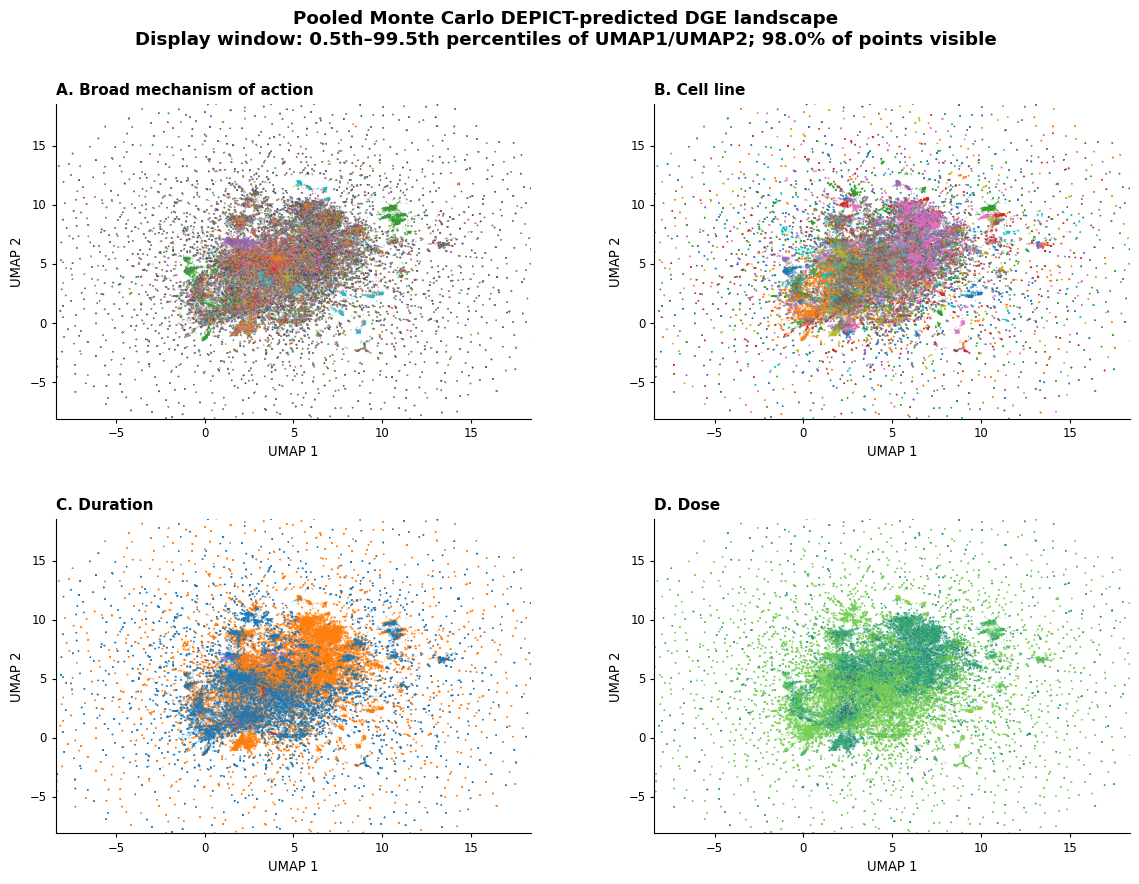

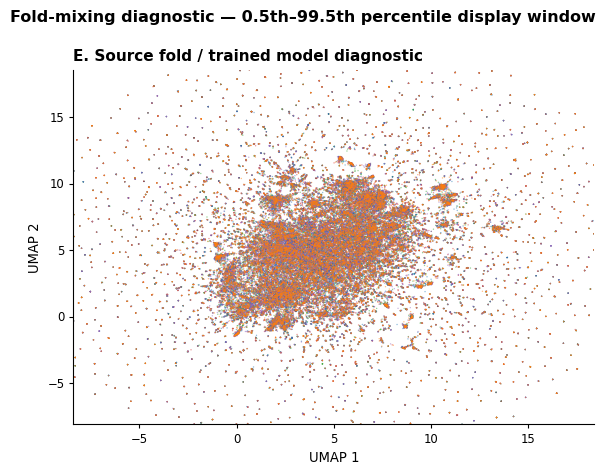

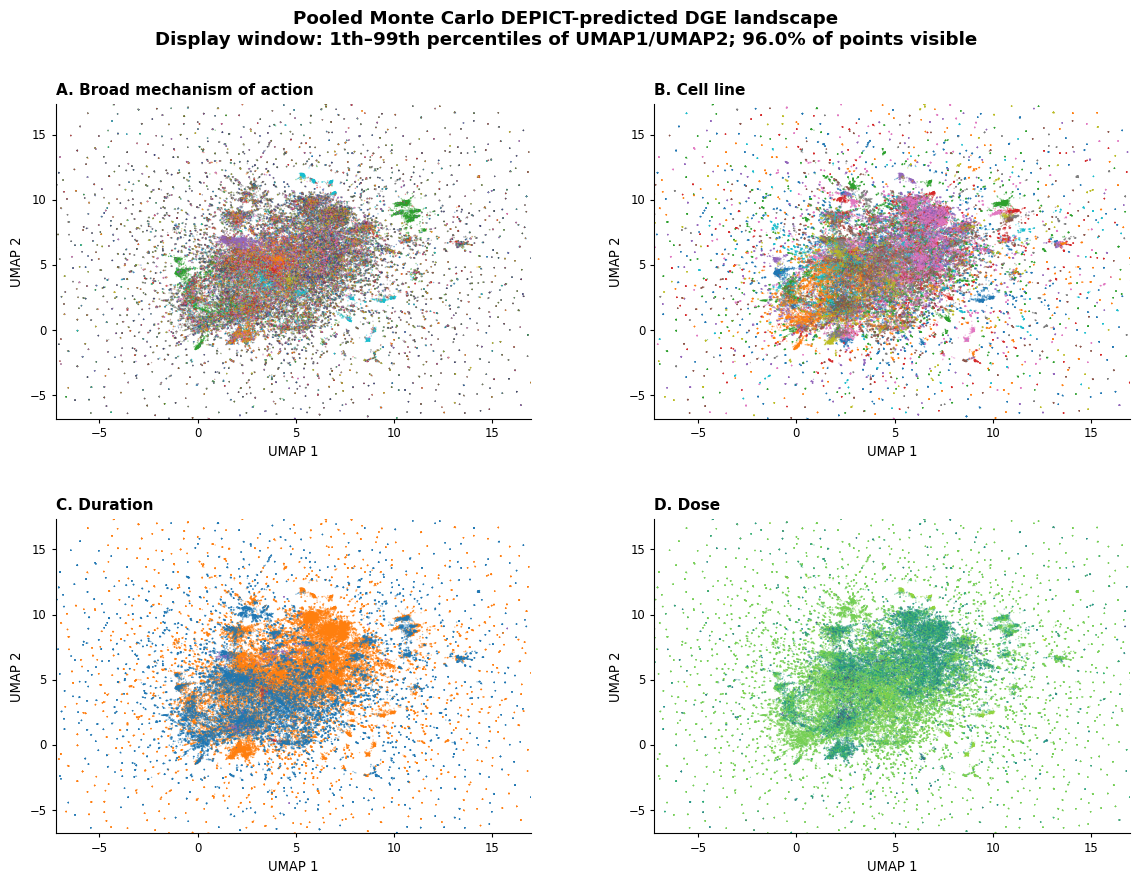

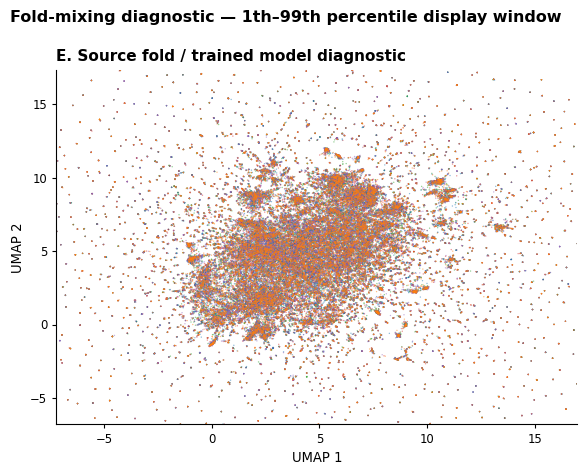

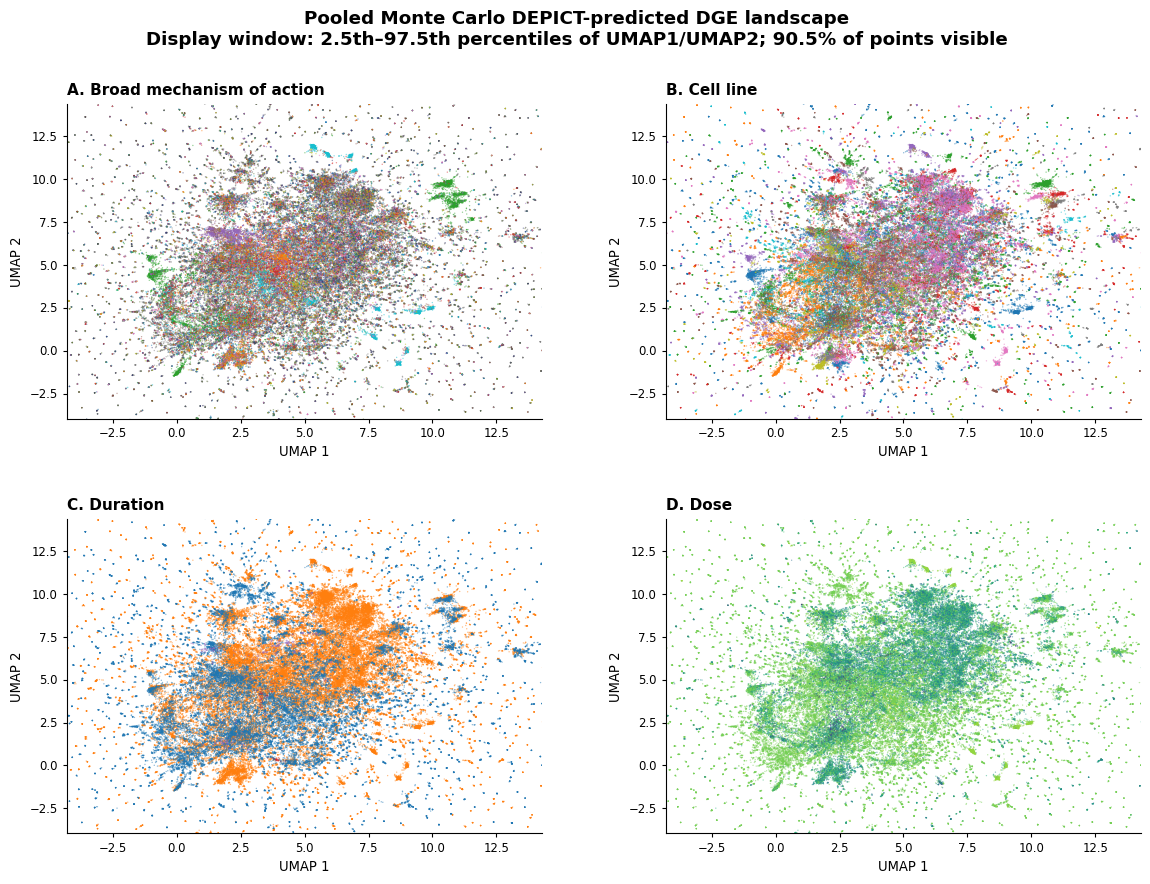

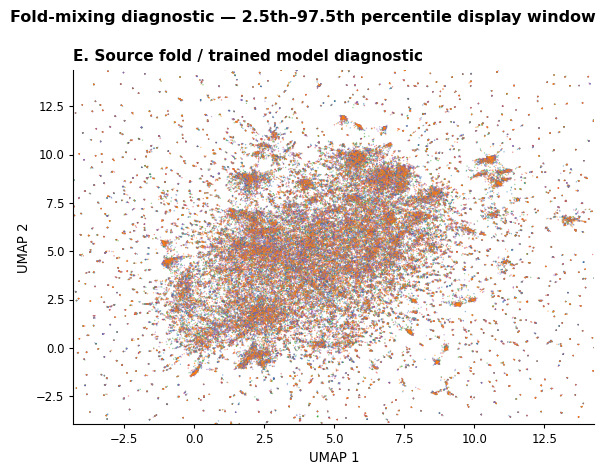

 lower_percentile  upper_percentile     x_min     x_max     y_min     y_max  n_points_total  n_points_visible  fraction_points_visible
              0.5              99.5 -8.390819 18.386881 -8.100056 18.501605           92703             90847                 0.979979
              1.0              99.0 -7.227748 16.972875 -6.793228 17.312708           92703             88991                 0.959958
              2.5              97.5 -4.311292 14.290151 -3.965941 14.369600           92703             83852                 0.904523

Recommended main-text files: crop_2p5_97p5/. Panels A-D are equal in size; scatter layers are embedded at 600 dpi; axes/text/legends/colorbar remain vector; Panel D colorbar is separate.


In [4]:
# 3. Generate hybrid 600-dpi PDFs with equal panels and separate legends/colorbar
crop_summary_rows = []

for lower, upper in CROP_SCHEMES:
    xlim, ylim = percentile_limits(xy, lower, upper)

    inside = (
        (xy[:, 0] >= xlim[0])
        & (xy[:, 0] <= xlim[1])
        & (xy[:, 1] >= ylim[0])
        & (xy[:, 1] <= ylim[1])
    )
    retained_display_fraction = float(np.mean(inside))

    crop_name = f"crop_{str(lower).replace('.', 'p')}_{str(upper).replace('.', 'p')}"
    crop_dir = OUT_ROOT / crop_name
    crop_dir.mkdir(parents=True, exist_ok=True)

    # Panels A-D: equal axes sizes, no legends, no colorbar inside the 2x2 figure.
    fig, axes = plt.subplots(
        2, 2,
        figsize=MAIN_FIGSIZE,
        gridspec_kw={"wspace": 0.26, "hspace": 0.32},
    )

    categorical_plot(
        axes[0, 0], xy, coords_df["broad_moa"],
        "A. Broad mechanism of action",
        order=MOA_ORDER,
        fixed_colors=MOA_COLOR_MAP,
        show_legend=False,
    )
    categorical_plot(
        axes[0, 1], xy, coords_df["cell_id"],
        "B. Cell line",
        order=GLOBAL_TOP10_CELLS,
        fixed_colors=CELL_COLOR_MAP,
        show_legend=False,
    )
    duration_plot(
        axes[1, 0], xy, coords_df["pert_time"],
        "C. Duration",
        show_legend=False,
    )
    dose_plot(
        axes[1, 1], xy, coords_df["dose"],
        "D. Dose",
    )

    for ax in axes.flat:
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

    fig.suptitle(
        "Pooled Monte Carlo DEPICT-predicted DGE landscape\n"
        f"Display window: {lower:g}th–{upper:g}th percentiles of UMAP1/UMAP2; "
        f"{retained_display_fraction:.1%} of points visible",
        fontsize=SUPTITLE_FONTSIZE,
        fontweight="bold",
        y=0.995,
    )
    fig.subplots_adjust(left=0.075, right=0.97, bottom=0.08, top=0.89)

    fig.savefig(
        crop_dir / "PanelsAtoD_Hybrid600dpi_EqualPanels_PlotsOnly.pdf",
        format="pdf",
        dpi=SCATTER_RASTER_DPI,
        bbox_inches="tight",
        pad_inches=0.05,
    )
    plt.show()
    plt.close(fig)

    # Separate vector legends and dose colorbar.
    save_categorical_legend_pdf(
        coords_df["broad_moa"],
        crop_dir / "Legend_PanelA_BroadMoA.pdf",
        order=MOA_ORDER,
        fixed_colors=MOA_COLOR_MAP,
        title="Broad mechanism of action",
        ncol=1,
    )
    save_categorical_legend_pdf(
        coords_df["cell_id"],
        crop_dir / "Legend_PanelB_CellLine.pdf",
        order=GLOBAL_TOP10_CELLS,
        fixed_colors=CELL_COLOR_MAP,
        title="Cell line",
        ncol=1,
    )
    save_categorical_legend_pdf(
        coords_df["pert_time"],
        crop_dir / "Legend_PanelC_Duration.pdf",
        order=sorted(
            pd.Series(coords_df["pert_time"]).astype(str).unique(),
            key=numeric_sort_key,
        ),
        fixed_colors=DURATION_COLOR_MAP,
        title="Duration",
        duration_suffix=True,
        ncol=1,
    )
    save_dose_colorbar_pdf(
        coords_df["dose"],
        crop_dir / "Colorbar_PanelD_Dose.pdf",
    )

    # Panel E: hybrid 600-dpi plot-only PDF plus separate vector legend.
    fig, ax = plt.subplots(figsize=(6.2, 4.85))
    categorical_plot(
        ax, xy, coords_df["source_fold"],
        "E. Source fold / trained model diagnostic",
        order=FOLD_ORDER,
        fixed_colors=FOLD_COLOR_MAP,
        show_legend=False,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    fig.suptitle(
        f"Fold-mixing diagnostic — {lower:g}th–{upper:g}th percentile display window",
        fontsize=11.5,
        fontweight="bold",
        y=0.985,
    )
    fig.subplots_adjust(left=0.13, right=0.97, bottom=0.13, top=0.86)
    fig.savefig(
        crop_dir / "PanelE_SourceFold_Hybrid600dpi_PlotOnly.pdf",
        format="pdf",
        dpi=SCATTER_RASTER_DPI,
        bbox_inches="tight",
        pad_inches=0.05,
    )
    plt.show()
    plt.close(fig)

    save_categorical_legend_pdf(
        coords_df["source_fold"],
        crop_dir / "Legend_PanelE_SourceFold.pdf",
        order=FOLD_ORDER,
        fixed_colors=FOLD_COLOR_MAP,
        title="Source fold / trained model",
        ncol=1,
    )

    crop_summary_rows.append({
        "lower_percentile": lower,
        "upper_percentile": upper,
        "x_min": xlim[0],
        "x_max": xlim[1],
        "y_min": ylim[0],
        "y_max": ylim[1],
        "n_points_total": len(xy),
        "n_points_visible": int(inside.sum()),
        "fraction_points_visible": retained_display_fraction,
    })

crop_summary = pd.DataFrame(crop_summary_rows)
crop_summary.to_csv(OUT_ROOT / "crop_window_summary.csv", index=False)
print(crop_summary.to_string(index=False))
print(
    "\nRecommended main-text files: crop_2p5_97p5/. "
    "Panels A-D are equal in size; scatter layers are embedded at 600 dpi; "
    "axes/text/legends/colorbar remain vector; Panel D colorbar is separate."
)



## Reporting recommendation

These cropped figures should be described as **display-window restrictions only**. All profiles remain in PCA and UMAP fitting. A suitable Methods/figure-note statement is:

> “For visualization, UMAP axes were restricted to pre-specified percentile windows of the full UMAP coordinate distributions; all profiles were retained during PCA and UMAP fitting.”

The full uncropped Module 2C figure should remain available in supplementary material or as a diagnostic.
